## Machine Learning Workflow

A typical machine learning workflow involves several key steps:

1.  **Problem Definition:** Clearly define the problem you're trying to solve (e.g., classification, regression, clustering) and the desired outcome.

2.  **Data Collection:** Gather relevant data from various sources.

3.  **Data Preprocessing/Cleaning:** This is a crucial step that involves:
    *   **Handling Missing Values:** Imputing or removing missing data points.
    *   **Data Type Conversion:** Ensuring columns have appropriate data types (e.g., numeric, categorical, datetime).
    *   **Handling Outliers:** Identifying and addressing extreme values.
    *   **Feature Engineering:** Creating new features from existing ones to improve model performance.
    *   **Data Scaling/Normalization:** Scaling numerical features to a standard range to prevent certain features from dominating the learning process.

4.  **Exploratory Data Analysis (EDA):** Understand the data's distribution, relationships between variables, patterns, and potential anomalies using visualizations and statistical summaries.

5.  **Feature Selection/Extraction:** Choose the most relevant features or create new ones to reduce dimensionality and improve model efficiency and accuracy.

6.  **Model Selection:** Choose an appropriate machine learning algorithm based on the problem type and data characteristics.

7.  **Training:** Train the chosen model on the prepared dataset.

8.  **Evaluation:** Assess the model's performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score for classification; RMSE, MAE for regression) on a separate test set.

9.  **Hyperparameter Tuning:** Optimize model parameters to achieve better performance.

10. **Deployment:** Integrate the trained model into a production environment.

11. **Monitoring and Maintenance:** Continuously monitor the model's performance in production and retrain it as needed with new data.

Dataset: [Student Placement (with missing values)](https://drive.google.com/file/d/1XjLdfW5cKgnCncQNvyIfvG19aqakCDFt/view?usp=drive_link)

In [70]:
import pandas as pd

def show_info(df, target, features):
    # Get rows and columns
    print(f"Dataset Basic Info:")
    print("-" * 50)
    print(f"+ Rows: {df.shape[0]}; Columns: {df.shape[1]}")
    print(f"+ Unique Labels: {df[target].nunique()}")

    label_counts = {label: count for label, count in df[target].value_counts().items()}
    print(f"+ Value counts of each label\n: {label_counts}")
    print(f"+ Features: {features}")
    print("-" * 50)

    # Show info
    df.info()

In [71]:
# Read the dataset
df = pd.read_csv('college_placement.csv')
# Inspect dataset
show_info(df, target='Placement', features=df.columns.drop('Placement'))

Dataset Basic Info:
--------------------------------------------------
+ Rows: 10200; Columns: 10
+ Unique Labels: 2
+ Value counts of each label
: {'No': 8457, 'Yes': 1743}
+ Features: Index(['IQ', 'Major', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed'],
      dtype='object')
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      10190 non-null  float64
 1   Major                   10200 non-null  object 
 2   Prev_Sem_Result         10161 non-null  float64
 3   CGPA                    10179 non-null  float64
 4   Academic_Performance    10179 non-null  float64
 5   Internship_Experience   10171 non-null  object 
 6   Extra_Curricular_S

In [72]:
# Define target and features
target = 'Placement'
features = df.columns.drop(target)

X = df[features]
y = df[target]

In [73]:
# Numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed']
Categorical Columns: ['Major', 'Internship_Experience', 'Placement']


In [74]:
# Identify binary and multi-class categorical columns
binary_cols = [col for col in cat_cols if df[col].nunique() == 2 and col != target]
multi_class_cols = [col for col in cat_cols if df[col].nunique() > 2]

print("Binary Columns:", binary_cols)
print("Multi-Class Columns:", multi_class_cols)

Binary Columns: ['Internship_Experience']
Multi-Class Columns: ['Major']


### Identify Nullable Integer Columns

This step attempts to identify columns that are meant to be integers but contain `NaN` values, which pandas typically represents as `float64` for nullable integer columns by default before `Int64` (nullable integer) type was more widely used or explicitly specified. It tries to convert columns to 'Int64' and lists those that succeed, indicating they are candidates for nullable integer imputation.

In [75]:
# Detect nullable integer columns
nullable_int_cols = []

for col in num_cols:
    try:
        df[col].astype('Int64')  # Try converting
        nullable_int_cols.append(col)
    except:
        pass

print("Nullable Integer Columns:", nullable_int_cols)

Nullable Integer Columns: ['IQ', 'Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed']


### Identify Remaining Numerical Columns

After identifying `nullable_int_cols`, this cell determines which numerical columns are left. These are typically `float64` columns that might contain non-integer values or `NaN`s that aren't intended to be `Int64` (like `Prev_Sem_Result` and `CGPA`).

In [76]:
# Remaining numerical columns
remaining_num_cols = [col for col in num_cols if col not in nullable_int_cols]

print("Remaining Columns:", remaining_num_cols)

Remaining Columns: ['Prev_Sem_Result', 'CGPA']


### Impute Missing Values

This crucial data preprocessing step fills in missing values (`NaN`) in the dataset:

*   **Binary and Multi-Class Categorical Columns:** Missing values in these columns are imputed with their **mode** (the most frequent value). This is a common strategy for categorical data.
*   **Nullable Integer Columns:** These are first explicitly cast to `Int64` (pandas' nullable integer type) and then missing values are imputed with their **mode**. This ensures that imputed values are integers.
*   **Remaining Numerical Columns:** Missing values in these columns (like `Prev_Sem_Result` and `CGPA`) are imputed with their **mean**. This is a standard practice for continuous numerical data.

In [77]:
# Impute binary and multi columns with mode
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in multi_class_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute nullable integer columns with mode
for col in nullable_int_cols:
    df[col] = df[col].astype('Int64')
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute remaining numerical columns with mean
for col in remaining_num_cols:
    df[col] = df[col].fillna(df[col].mean())

### Verify Missing Values and Data Types

After imputation, it's essential to confirm that all missing values have been handled and that the data types are as expected. This cell performs two checks:

1.  `df.isnull().sum()`: Prints the count of missing values for each column, which should ideally all be zero.
2.  `df.info()`: Displays a summary of the DataFrame, including the column data types and non-null counts, to ensure the types are correct (e.g., `Int64` for previously nullable integers).

In [78]:
# Check missing values again
print(df.isnull().sum())

# Check data types
df.info()

IQ                        0
Major                     0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      10200 non-null  Int64  
 1   Major                   10200 non-null  object 
 2   Prev_Sem_Result         10200 non-null  float64
 3   CGPA                    10200 non-null  float64
 4   Academic_Performance    10200 non-null  Int64  
 5   Internship_Experience   10200 non-null  object 
 6   Extra_Curricular_Score  10200 non-null  Int64  
 7   Communication_Skills    10200 non-null  Int64  
 8   Projects_Completed      10200 non-null  Int64  
 9   Placement 

### Prepare for Oversampling

This block sets up the dataset for handling class imbalance, a common problem in classification tasks where one class has significantly fewer instances than others. It first creates a copy of the DataFrame (`df_combined`) and then separates the dataset into two groups based on the target variable ('Placement'): the majority class ('No' placement) and the minority class ('Yes' placement). Finally, it prints the class distribution *before* oversampling to show the imbalance.

In [79]:
import numpy as np

# Combine features and target for easier manipulation
df_combined = df.copy()

# Separate majority and minority classes
majority_class = df_combined[df_combined[target] == 'No']
minority_class = df_combined[df_combined[target] == 'Yes']

print("Before Sampling:")
print(df_combined[target].value_counts())

Before Sampling:
Placement
No     8457
Yes    1743
Name: count, dtype: int64


### Oversample Minority Class

To address class imbalance, this step uses **oversampling**. It randomly samples from the minority class ('Yes' placement) with replacement (`replace=True`) until its size matches that of the majority class. This creates duplicate instances of the minority class, effectively balancing the dataset without losing information from the majority class.

In [80]:
# Oversample minority class
minority_oversampled = minority_class.sample(n=len(majority_class), replace=True, random_state=42)

### Combine and Shuffle Balanced Data

After oversampling, the oversampled minority class is concatenated with the original majority class to form a new, balanced DataFrame (`df_balanced`). The `frac=1` argument in `sample()` shuffles the entire DataFrame, ensuring that the order of instances is randomized and not biased towards the original class distribution. `reset_index(drop=True)` creates a new clean index.

In [81]:
# Combine majority and oversampled minority
df_balanced = pd.concat([majority_class, minority_oversampled])

# Shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

### Verify Class Distribution After Sampling

This cell simply prints the value counts of the target variable (`Placement`) in the `df_balanced` DataFrame. This step confirms that the oversampling process was successful and that both classes now have an equal number of instances, indicating a balanced dataset for model training.

In [82]:
print("After Sampling:")
print(df_balanced['Placement'].value_counts())

After Sampling:
Placement
Yes    8457
No     8457
Name: count, dtype: int64


### One-Hot Encoding for 'Major'

Categorical features, like 'Major', need to be converted into a numerical format for most machine learning models. **One-Hot Encoding** creates new binary columns for each unique category in the 'Major' column. For example, if 'Major' has 'CSE', 'ECE', 'MECH', it will create 'Major_CSE', 'Major_ECE', 'Major_MECH'. A '1' indicates the presence of that major, and '0' indicates its absence. `dtype=int` ensures the new columns contain 0s and 1s instead of booleans.

In [83]:
# One-Hot Encoding for 'Major'
# dtype=int makes values 0 and 1 instead of True/False)
df_encoded = pd.get_dummies(df_balanced, columns=['Major'], dtype=int)

### Map Binary Categorical Column 'Internship_Experience'

The 'Internship_Experience' column is a binary categorical feature ('Yes'/'No'). This step converts these string values into numerical representations: 'Yes' is mapped to `1`, and 'No' is mapped to `0`. This is a direct numerical encoding for binary features, which is suitable for many models.

In [84]:
# Map binary column
df_encoded['Internship_Experience'] = df_encoded['Internship_Experience'].map({'Yes': 1, 'No': 0})

### Map Target Variable 'Placement'

Similar to `Internship_Experience`, the target variable 'Placement' is also a binary categorical feature ('Yes'/'No'). This step converts 'Yes' to `1` and 'No' to `0`. This numerical encoding is crucial because machine learning models typically require numerical inputs for the target variable during training.

In [85]:
df_encoded[target] = df_encoded[target].map({'Yes': 1, 'No': 0})

### Standardize Numerical Features

**Standardization** is a preprocessing technique that scales numerical features so they have a mean of 0 and a standard deviation of 1. This is important for many machine learning algorithms (like those based on distance calculations, e.g., K-Means, SVM, or those using gradient descent) because it prevents features with larger numerical ranges from disproportionately influencing the model. The `StandardScaler` is fitted on the training data and then used to transform both training and testing data to avoid data leakage.

In [86]:
from sklearn.preprocessing import StandardScaler

# Separate features and target again
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Identify numerical columns (after encoding)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Apply Standardization
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

### Split Data into Training and Testing Sets

To evaluate a machine learning model's performance accurately, the data is split into two subsets:

*   **Training Set (`X_train`, `y_train`):** Used to train the model, allowing it to learn the patterns and relationships in the data.
*   **Testing Set (`X_test`, `y_test`):** Used to evaluate the trained model's performance on unseen data. This provides an unbiased estimate of how the model will perform in a real-world scenario.

`test_size=0.2` means 20% of the data will be used for testing, and 80% for training. `random_state=42` ensures reproducibility, and `stratify=y` ensures that the proportion of classes in the target variable (`y`) is maintained in both the training and testing sets, which is particularly important for imbalanced datasets.

In [87]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

#### Supervised Learning

Supervised learning is a type of machine learning where the model learns from labeled data, meaning the input data is paired with the correct output. The goal is to learn a mapping from inputs to outputs so that the model can predict the output for new, unseen inputs.

### Define Model Training and Evaluation Function

This cell defines a reusable function `train_evaluate_model` that streamlines the process of training a machine learning model and evaluating its performance. It takes a model object and its name as input, then:

1.  **Trains** the model on the `X_train` and `y_train` data.
2.  **Predicts** outcomes on the `X_test` data.
3.  **Calculates and prints** key classification metrics: Confusion Matrix, Accuracy, Precision, Recall, and F1-Score.
4.  **Returns** the confusion matrix and a dictionary of all evaluated metrics for later aggregation.

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_evaluate_model(model, name):
    print("Model:", name)

    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1score = f1_score(y_test, y_pred)

    print(f"Confusion Matrix:\n{conf_matrix}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1score}\n")

    return conf_matrix, {"Model": name, "Accuracy": accuracy, "Precision": precision,
                         "Recall": recall, "F1-Score": f1score}

### Train and Evaluate Supervised Learning Models

This block sets up and runs several common supervised classification models:

*   **Logistic Regression:** A linear model for binary classification.
*   **Decision Tree Classifier:** A tree-based model that makes decisions by splitting data based on feature values.
*   **Random Forest Classifier:** An ensemble method that builds multiple decision trees and combines their predictions.
*   **Gradient Boosting Classifier:** Another ensemble method that builds trees sequentially, where each new tree corrects errors of the previous ones.

Each model is instantiated with specific hyperparameters (e.g., `random_state` for reproducibility, `n_estimators` for ensemble methods). The `train_evaluate_model` function is then called for each model, and their performance metrics (confusion matrix, accuracy, precision, recall, F1-score) are collected and printed, allowing for a comparison of their effectiveness.

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    LogisticRegression(solver='liblinear', random_state=42): 'Logistic Regression',
    DecisionTreeClassifier(criterion='entropy', random_state=42): 'Decision Tree',
    RandomForestClassifier(n_estimators=100, random_state=42): "Random Forest",
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42): "Gradient Boosting"
}

results = []
cfm_results = []

for model, name in models.items():
    cfm, res = train_evaluate_model(model, name)
    results.append(res)
    cfm_results.append(cfm)

Model: Logistic Regression
Confusion Matrix:
[[1416  276]
 [ 246 1445]]
Accuracy: 0.845699083653562
Precision: 0.8396281231841952
Recall: 0.8545239503252513
F1-Score: 0.847010550996483

Model: Decision Tree
Confusion Matrix:
[[1682   10]
 [   0 1691]]
Accuracy: 0.9970440437481525
Precision: 0.9941211052322163
Recall: 1.0
F1-Score: 0.9970518867924528

Model: Random Forest
Confusion Matrix:
[[1689    3]
 [   0 1691]]
Accuracy: 0.9991132131244458
Precision: 0.9982290436835891
Recall: 1.0
F1-Score: 0.9991137370753324

Model: Gradient Boosting
Confusion Matrix:
[[1687    5]
 [   1 1690]]
Accuracy: 0.9982264262488915
Precision: 0.9970501474926253
Recall: 0.9994086339444116
F1-Score: 0.9982279976373302



#### Unsupervised Learning

Unsupervised learning is a type of machine learning that deals with unlabeled data. The goal is to find hidden patterns, structures, or relationships within the data without any explicit guidance on the desired output.

### K-Means Clustering for Unsupervised Learning

This cell defines a function `clustering_model` to perform K-Means clustering, an unsupervised learning algorithm used for grouping data points into `k` distinct clusters based on their similarity.

1.  **Feature Extraction:** Selects two specified features (`x` and `y`) from the DataFrame.
2.  **Standardization:** Scales these features using `StandardScaler` to ensure that no single feature dominates the clustering process.
3.  **K-Means:** Initializes and fits a `KMeans` model with a specified number of `clusters`.
4.  **Cluster Assignment:** Assigns each data point to a cluster.
5.  **Evaluation:** Calculates the **Silhouette Score**, which measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.
6.  **Visualization:** Plots the data points, colored by their assigned cluster, to visually represent the clustering results.


Silhouette Score: 0.3304


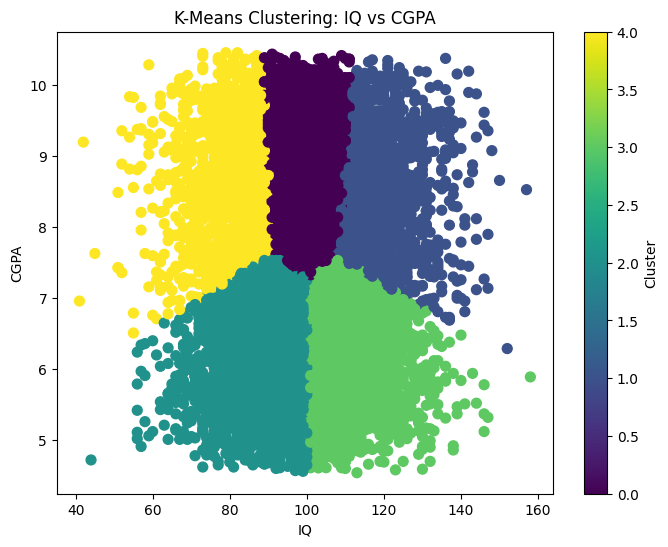

In [90]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def clustering_model(x, y, clusters=3):
    # Extract relevant features
    data = df[[x, y]]

    # Standardize
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # K-Means
    kmeans = KMeans(n_clusters=clusters, random_state=42)
    kmeans.fit(data_scaled)

    # Assign clusters
    df['Cluster'] = kmeans.labels_

    # Evaluate clustering
    sil_score = silhouette_score(data_scaled, kmeans.labels_)
    print(f"Silhouette Score: {sil_score:.4f}")

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(df[x], df[y], c=df['Cluster'], cmap='viridis', s=50)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'K-Means Clustering: {x} vs {y}')
    plt.colorbar(label='Cluster')
    plt.show()

# Run clustering
clustering_model(x='IQ', y='CGPA', clusters=5)

#### Semi-Supervised Learning

Semi-supervised learning is a machine learning paradigm that combines aspects of both supervised and unsupervised learning. It uses a small amount of labeled data along with a large amount of unlabeled data during training. The goal is to improve the learning accuracy compared to using only labeled data, and to reduce the effort of manual data labeling.

### Label Propagation for Semi-Supervised Learning

This cell demonstrates **Label Propagation**, a semi-supervised learning algorithm. It uses a small set of labeled data to infer labels for a larger set of unlabeled data.

1.  **Label Copy and Unlabeling:** A copy of the target labels (`y_unlabeled`) is created, and 80% of these labels are artificially set to -1 (representing unlabeled data).
2.  **Feature Preparation:** Features (`X`) are prepared, and the target variable is mapped for semi-supervised training.
3.  **Scaling:** Features are scaled using `StandardScaler`.
4.  **Model Training:** A `LabelPropagation` model is initialized and trained on the scaled features and the partially labeled target variable. The model propagates labels through the dataset based on similarity between data points.
5.  **Prediction and Evaluation:** After propagation, the model's inferred labels (`y_pred`) are evaluated against the original true labels (`y_true`) using standard classification metrics (Confusion Matrix, Accuracy, Precision, Recall, F1-Score) and also the Adjusted Rand Index (ARI), which measures the similarity between two clusterings (in this case, the true labels and the propagated labels).

In [93]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Use the preprocessed and encoded DataFrame for features and true labels
X_semi = df_encoded.drop(columns=[target])
y_true_semi = df_encoded[target]

# Copy labels for semi-supervised learning setup
y_unlabeled_semi = y_true_semi.copy()

# Artificially remove 80% of labels for demonstration by setting them to -1
unlabeled_indices = y_true_semi.sample(frac=0.8, random_state=42).index
y_unlabeled_semi.loc[unlabeled_indices] = -1

# Scale features
scaler_semi = StandardScaler()
X_scaled_semi = scaler_semi.fit_transform(X_semi)

# Model
# Note: LabelPropagation expects numerical labels (0, 1, ...) or -1 for unlabeled data
# Changed kernel to 'knn' and added n_neighbors for faster computation
model_semi = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=5000)
model_semi.fit(X_scaled_semi, y_unlabeled_semi)

# Predictions - the transduction_ attribute gives the inferred labels
y_pred_semi = model_semi.transduction_

# Evaluation against the original true labels
print("Confusion Matrix:\n", confusion_matrix(y_true_semi, y_pred_semi))
print("Accuracy:", accuracy_score(y_true_semi, y_pred_semi))
print("Precision:", precision_score(y_true_semi, y_pred_semi))
print("Recall:", recall_score(y_true_semi, y_pred_semi))
print("F1 Score:", f1_score(y_true_semi, y_pred_semi))
print("ARI:", adjusted_rand_score(y_true_semi, y_pred_semi))

Confusion Matrix:
 [[7055 1402]
 [1509 6948]]
Accuracy: 0.8278940522643964
Precision: 0.8320958083832335
Recall: 0.8215679318907414
F1 Score: 0.8267983578270959
ARI: 0.4300243429893906


### Visualize Label Propagation Results

This cell visualizes the impact of the Label Propagation algorithm. It generates two scatter plots:

1.  **Before propagation — few labels:** Shows the initial state where only a small portion of the data points are labeled (colored), while the majority are unlabeled (grey).
2.  **After propagation — all labeled:** Shows the state after the Label Propagation model has inferred labels for all data points. The points are now colored according to their propagated labels, illustrating how the algorithm has effectively labeled the previously unlabeled data based on the patterns learned from the few initial labels.

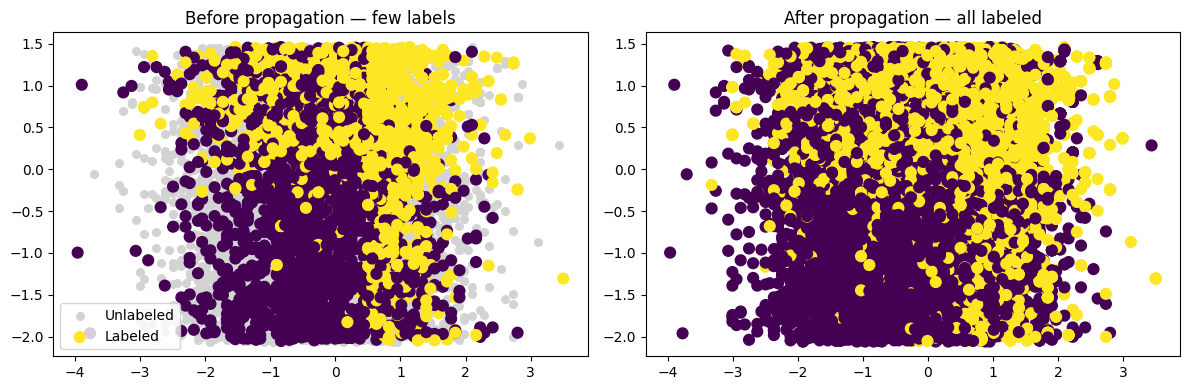

In [ ]:
import matplotlib.pyplot as plt

# Mask labeled data
mask = y_unlabeled_semi != -1

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Before
ax[0].scatter(X_scaled_semi[:, 0], X_scaled_semi[:, 1], c='lightgray', s=30, label='Unlabeled')
ax[0].scatter(X_scaled_semi[mask, 0], X_scaled_semi[mask, 1], c=y_true_semi[mask], cmap='viridis', s=60, label='Labeled')
ax[0].set_title("Before propagation — few labels")
ax[0].legend()

# After
ax[1].scatter(X_scaled_semi[:, 0], X_scaled_semi[:, 1], c=y_pred_semi, cmap='viridis', s=60)
ax[1].set_title("After propagation — all labeled")

plt.tight_layout()
plt.show()